<a href="https://colab.research.google.com/github/dhrona007/E-Commerce-Revenue-Profit-Analysis/blob/main/E_commerce_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E-commerce Analytics Project

**This consists of various tasks which covers questions of commerce platform**

## Pre-requisites

### Import required Libraries

In [267]:
# step 1
# Import libraries required

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Load & Understand Data

In [268]:
orders_items = pd.read_csv('/content/order_items_shopease.csv')
print("Order Items Table Info: \n")
orders_items.info()

print("\n\n Order Items Table View: ")
orders_items.head()

Order Items Table Info: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12389 entries, 0 to 12388
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   order_id    12389 non-null  object
 1   product_id  12389 non-null  object
 2   quantity    12389 non-null  int64 
 3   price       12389 non-null  int64 
 4   discount    12389 non-null  object
dtypes: int64(2), object(3)
memory usage: 484.1+ KB


 Order Items Table View: 


,order_id,product_id,quantity,price,discount
0,ORD_10001,PROD_203,3,540,10%
1,ORD_10001,PROD_220,3,1061,5%
2,ORD_10001,PROD_177,3,929,0%
3,ORD_10002,PROD_105,3,1664,10%
4,ORD_10002,PROD_227,3,592,5%


In [269]:
products = pd.read_csv('/content/products_shopease.csv')
products.head()

,product_id,product_name,category,sub_category,brand,cost_price
0,PROD_1,Wireless Headphones SoundMax,Electronics,Audio,SoundMax,1698
1,PROD_2,Wireless Headphones AudioPro,Electronics,Audio,AudioPro,1555
2,PROD_3,Wireless Headphones BassKing,Electronics,Audio,BassKing,1279
3,PROD_4,Bluetooth Speaker SoundMax,Electronics,Audio,SoundMax,216
4,PROD_5,Bluetooth Speaker AudioPro,Electronics,Audio,AudioPro,1890


In [270]:
orders = pd.read_csv('/content/orders_shopease.csv')
print("Order Table Info: \n")
orders.info()

print("\n\nOrder Table view: ")
orders.head()

Order Table Info: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   order_id        5000 non-null   object
 1   customer_id     5000 non-null   object
 2   order_date      5000 non-null   object
 3   order_value     5000 non-null   int64 
 4   payment_method  5000 non-null   object
 5   status          5000 non-null   object
 6   city            5000 non-null   object
dtypes: int64(1), object(6)
memory usage: 273.6+ KB


Order Table view: 


,order_id,customer_id,order_date,order_value,payment_method,status,city
0,ORD_10001,CUST_8269,2024-04-21,547,Netbanking,Delivered,Chennai
1,ORD_10002,CUST_8355,2024-01-13,996,Netbanking,Delivered,Hyderabad
2,ORD_10003,CUST_7965,2024-02-10,4180,UPI,Delivered,Mumbai
3,ORD_10004,CUST_8943,2024-01-28,1995,Netbanking,Delivered,Chennai
4,ORD_10005,CUST_1783,2023-12-31,2428,UPI,Delivered,Delhi


## Challenge - 1
#### Revenue Analysis

### 1. Calculate monthly revenue trends - Is revenue growing or declining?

From the given table view revenue is calculated as below:
* Change Date to Month format ``pd.to_date()``
* Add **month** column to the orders table using ``pd.to_period('M')``
* Calculate the Disount amount but before that
  * Replace the **%** using ``str.replace('%', '')``
  * Convert Discount Object type to float type using ``astype(float)``
  * Divide the convert float value by 100 to get the actual discount
* From the given table and the schema, revenue is calculated by below conditions:
  * price for each products and total no. of products order placed with discount on each product by creating a column in orders table as ``orders['total_bill'] = orders['price'] * orders['quantity'] * (1 - orders['discount'])``
  * Only the produts which are **Delivered** are considered as revenue
  * In order to get the monthly revenue, it needs to be done by using ``df.groupby('month')['total_bill'].sum()`` - which basically means group the monthly revenue and add them
  * Plot them in line chart and show the revenue trends over month using ```plt.plot(x_values, y_values)```

In [271]:
orders['order_date'] = pd.to_datetime(orders['order_date'])

orders.head()

,order_id,customer_id,order_date,order_value,payment_method,status,city
0,ORD_10001,CUST_8269,2024-04-21,547,Netbanking,Delivered,Chennai
1,ORD_10002,CUST_8355,2024-01-13,996,Netbanking,Delivered,Hyderabad
2,ORD_10003,CUST_7965,2024-02-10,4180,UPI,Delivered,Mumbai
3,ORD_10004,CUST_8943,2024-01-28,1995,Netbanking,Delivered,Chennai
4,ORD_10005,CUST_1783,2023-12-31,2428,UPI,Delivered,Delhi


In [272]:
# Adding Month to the orders table
orders['month'] = orders['order_date'].dt.to_period('M')

orders.head()

,order_id,customer_id,order_date,order_value,payment_method,status,city,month
0,ORD_10001,CUST_8269,2024-04-21,547,Netbanking,Delivered,Chennai,2024-04
1,ORD_10002,CUST_8355,2024-01-13,996,Netbanking,Delivered,Hyderabad,2024-01
2,ORD_10003,CUST_7965,2024-02-10,4180,UPI,Delivered,Mumbai,2024-02
3,ORD_10004,CUST_8943,2024-01-28,1995,Netbanking,Delivered,Chennai,2024-01
4,ORD_10005,CUST_1783,2023-12-31,2428,UPI,Delivered,Delhi,2023-12


In [273]:
# From order items table calculate the totoal price of each order
orders_items['total_bill'] = orders_items['quantity'] * orders_items['price'] * (1 - orders_items['discount'].str.replace('%' , '').astype(float) / 100)

orders_items.head()

,order_id,product_id,quantity,price,discount,total_bill
0,ORD_10001,PROD_203,3,540,10%,1458.00
1,ORD_10001,PROD_220,3,1061,5%,3023.85
2,ORD_10001,PROD_177,3,929,0%,2787.00
3,ORD_10002,PROD_105,3,1664,10%,4492.80
4,ORD_10002,PROD_227,3,592,5%,1687.20


In [274]:
# Join Table order_items & order

combined_orders_and_items_df = pd.merge(orders[['order_id', 'status', 'month']], orders_items[['order_id', 'total_bill']], how='inner', on='order_id')

print("Information of combined version of orders & orders_items:  \n")
combined_orders_and_items_df.info()

print("\n\n Combined Table view: ")
combined_orders_and_items_df.head()

Information of combined version of orders & orders_items:  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12389 entries, 0 to 12388
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype    
---  ------      --------------  -----    
 0   order_id    12389 non-null  object   
 1   status      12389 non-null  object   
 2   month       12389 non-null  period[M]
 3   total_bill  12389 non-null  float64  
dtypes: float64(1), object(2), period[M](1)
memory usage: 387.3+ KB


 Combined Table view: 


,order_id,status,month,total_bill
0,ORD_10001,Delivered,2024-04,1458.00
1,ORD_10001,Delivered,2024-04,3023.85
2,ORD_10001,Delivered,2024-04,2787.00
3,ORD_10002,Delivered,2024-01,4492.80
4,ORD_10002,Delivered,2024-01,1687.20


In [275]:
print("Types of unique values in status column:   ", combined_orders_and_items_df['status'].unique())

#Revenue Calculation
revenue = combined_orders_and_items_df[combined_orders_and_items_df['status'] == 'Delivered'].groupby('month')['total_bill'].sum()
revenue_df = revenue.reset_index()

print("Revenue Info: ")
print(revenue_df.info())

print("\n\n Revenue view: ")
revenue_df.head()

Types of unique values in status column:    ['Delivered' 'Cancelled' 'Returned']
Revenue Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype    
---  ------      --------------  -----    
 0   month       7 non-null      period[M]
 1   total_bill  7 non-null      float64  
dtypes: float64(1), period[M](1)
memory usage: 244.0 bytes
None


 Revenue view: 


,month,total_bill
0,2023-12,4292032.85
1,2024-01,4495647.55
2,2024-02,4434519.00
3,2024-03,4100102.60
4,2024-04,4123788.45


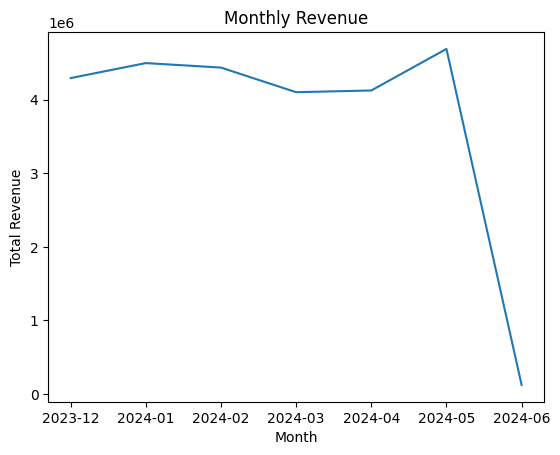

In [276]:

plt.plot(revenue_df["month"].astype(str), revenue_df["total_bill"])
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.title('Monthly Revenue')

plt.show()

### 2. Identify top revenue-generating months - When do we make the most money?

In [277]:
month_max_revenue = revenue_df.loc[revenue_df['total_bill'].idxmax(), 'month']
print(f"The Month with max revenue is: {month_max_revenue}")

The Month with max revenue is: 2024-05


### 3. Analyze revenue by payment method - Which payment methods drive the highest sales?

In [278]:
payment_types = orders[orders['status'] == 'Delivered'].groupby('payment_method')['order_value'].sum()

print(payment_types)

payment_method
COD           2372706
Card          2340735
Netbanking    2442067
UPI           2281654
Name: order_value, dtype: int64


In [279]:
# sorted values of the given payment methods uisng sort_vales()
payMethod_df = payment_types.reset_index()

payMethod_df = payMethod_df.sort_values(by='order_value')
payMethod_df.rename(columns = {'order_value' : 'salesBy_payment'} , inplace = True)
payMethod_df.head()

,payment_method,salesBy_payment
3,UPI,2281654
1,Card,2340735
0,COD,2372706
2,Netbanking,2442067


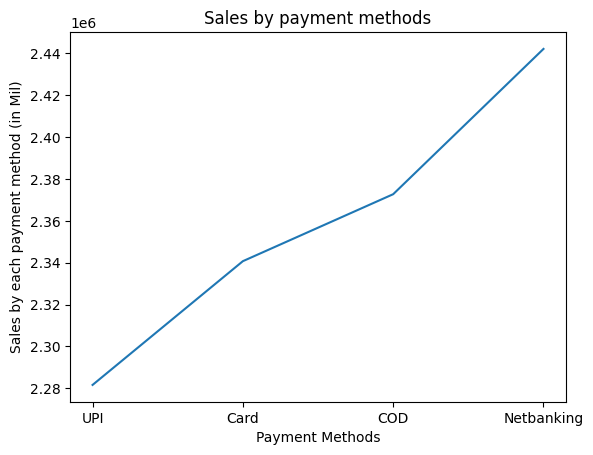

In [280]:
plt.plot(payMethod_df['payment_method'].astype(str), payMethod_df['salesBy_payment'])
plt.title('Sales by payment methods')
plt.xlabel('Payment Methods')
plt.ylabel('Sales by each payment method (in Mil)')

plt.show()

In [281]:
print("The payment method which made highest sales is: ", payMethod_df.loc[payMethod_df['salesBy_payment'].idxmax(), 'payment_method'], " \nThe sales of : " ,  payMethod_df['salesBy_payment'].max())

The payment method which made highest sales is:  Netbanking  
The sales of :  2442067


### 4. Calculate average order value (AOV) by city and month

In [282]:
city = orders.groupby('city').agg({'order_value' : 'mean'})
print(city)


           order_value
city                  
Bangalore  2878.671470
Chennai    2769.270233
Delhi      2784.282842
Hyderabad  2753.786014
Kolkata    2830.110512
Mumbai     2870.352601
Pune       2824.870968


In [283]:
month = orders.groupby('month').agg({'order_value' : 'mean'})
print(month)

         order_value
month               
2023-12  2753.129790
2024-01  2852.823050
2024-02  2820.913366
2024-03  2837.987879
2024-04  2763.837596
2024-05  2863.080045
2024-06  2534.933333


### 5. Find revenue contribution by category - Which product categories are most profitable?

In [284]:
combined_orders_and_items_df.head()

,order_id,status,month,total_bill
0,ORD_10001,Delivered,2024-04,1458.00
1,ORD_10001,Delivered,2024-04,3023.85
2,ORD_10001,Delivered,2024-04,2787.00
3,ORD_10002,Delivered,2024-01,4492.80
4,ORD_10002,Delivered,2024-01,1687.20


In [285]:
prod_catg_df = pd.merge(orders_items[['order_id', 'product_id', 'quantity']], products[['product_id', 'category','cost_price']], how='inner', on='product_id')

prod_catg_df['total_cost'] = prod_catg_df['quantity'] * prod_catg_df['cost_price']
prod_catg_df.head()

,order_id,product_id,quantity,category,cost_price,total_cost
0,ORD_10005,PROD_80,2,Sports,1630,3260
1,ORD_10007,PROD_35,3,Fashion,114,342
2,ORD_10008,PROD_47,3,Home & Kitchen,1037,3111
3,ORD_10009,PROD_24,2,Fashion,166,332
4,ORD_10009,PROD_48,2,Home & Kitchen,1851,3702


In [286]:
prod_revenue_categ_df = pd.merge(prod_catg_df, combined_orders_and_items_df[['order_id', 'status', 'total_bill']], on='order_id', how='inner')

prod_revenue_categ_df['total_profit'] = prod_revenue_categ_df['total_bill'] - prod_revenue_categ_df['total_cost']
prod_revenue_categ_df.head()

,order_id,product_id,quantity,category,cost_price,total_cost,status,total_bill,total_profit
0,ORD_10005,PROD_80,2,Sports,1630,3260,Delivered,1458.0,-1802.0
1,ORD_10005,PROD_80,2,Sports,1630,3260,Delivered,3101.0,-159.0
2,ORD_10005,PROD_80,2,Sports,1630,3260,Delivered,5565.0,2305.0
3,ORD_10005,PROD_80,2,Sports,1630,3260,Delivered,717.4,-2542.6
4,ORD_10007,PROD_35,3,Fashion,114,342,Cancelled,2436.0,2094.0


In [287]:
print("The unique values of status: " , prod_revenue_categ_df['status'].unique())

prod_revenue_categ_df = prod_revenue_categ_df[prod_revenue_categ_df['status'] == 'Delivered']

print("Combined Table view of Products and revenue: ")
prod_revenue_categ_df.head()



The unique values of status:  ['Delivered' 'Cancelled' 'Returned']
Combined Table view of Products and revenue: 


,order_id,product_id,quantity,category,cost_price,total_cost,status,total_bill,total_profit
0,ORD_10005,PROD_80,2,Sports,1630,3260,Delivered,1458.0,-1802.0
1,ORD_10005,PROD_80,2,Sports,1630,3260,Delivered,3101.0,-159.0
2,ORD_10005,PROD_80,2,Sports,1630,3260,Delivered,5565.0,2305.0
3,ORD_10005,PROD_80,2,Sports,1630,3260,Delivered,717.4,-2542.6
10,ORD_10009,PROD_24,2,Fashion,166,332,Delivered,4436.8,4104.8


In [288]:
category_product = prod_revenue_categ_df.groupby('category')['total_profit'].sum()
category_product.head()
category_product.sort_values(inplace = True)

category_product_df = category_product.reset_index()
category_product_df.head()

,category,total_profit
0,Books,711328.2
1,Sports,836144.5
2,Beauty,939234.0
3,Electronics,1084277.5
4,Home & Kitchen,1328409.1


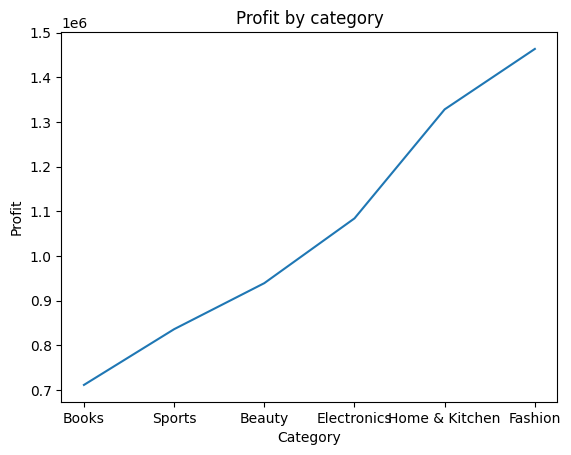

In [289]:
plt.plot(category_product.index.astype(str), category_product.values)
plt.xlabel('Category')
plt.ylabel('Profit')
plt.title('Profit by category')

plt.show()

In [290]:
# print(category_product_df.loc[category_product_df['total_profit'].idxmax(), 'category'])
print("The product category which made highest sales is: ")
print(category_product.idxmax())
print("Value of the category:")
print(category_product.max())

The product category which made highest sales is: 
Fashion
Value of the category:
1463712.05


## Summary
### Key findings
* Revenue is lowest in June, likely due to incomplete data rather than actual decline.
* Revenue peaks in May, indicating strong seasonal demand or possible promotional activity.
* Netbanking generates the highest revenue, suggesting a user preference for digital payment methods. Improving payment experience could further increase conversions.
* Average Order Value (AOV) varies across cities, indicating differences in purchasing power and customer behavior.
* The Fashion category generates the highest profit, making it a key revenue driver. Expanding offerings or targeted promotions in this category could enhance profitability.